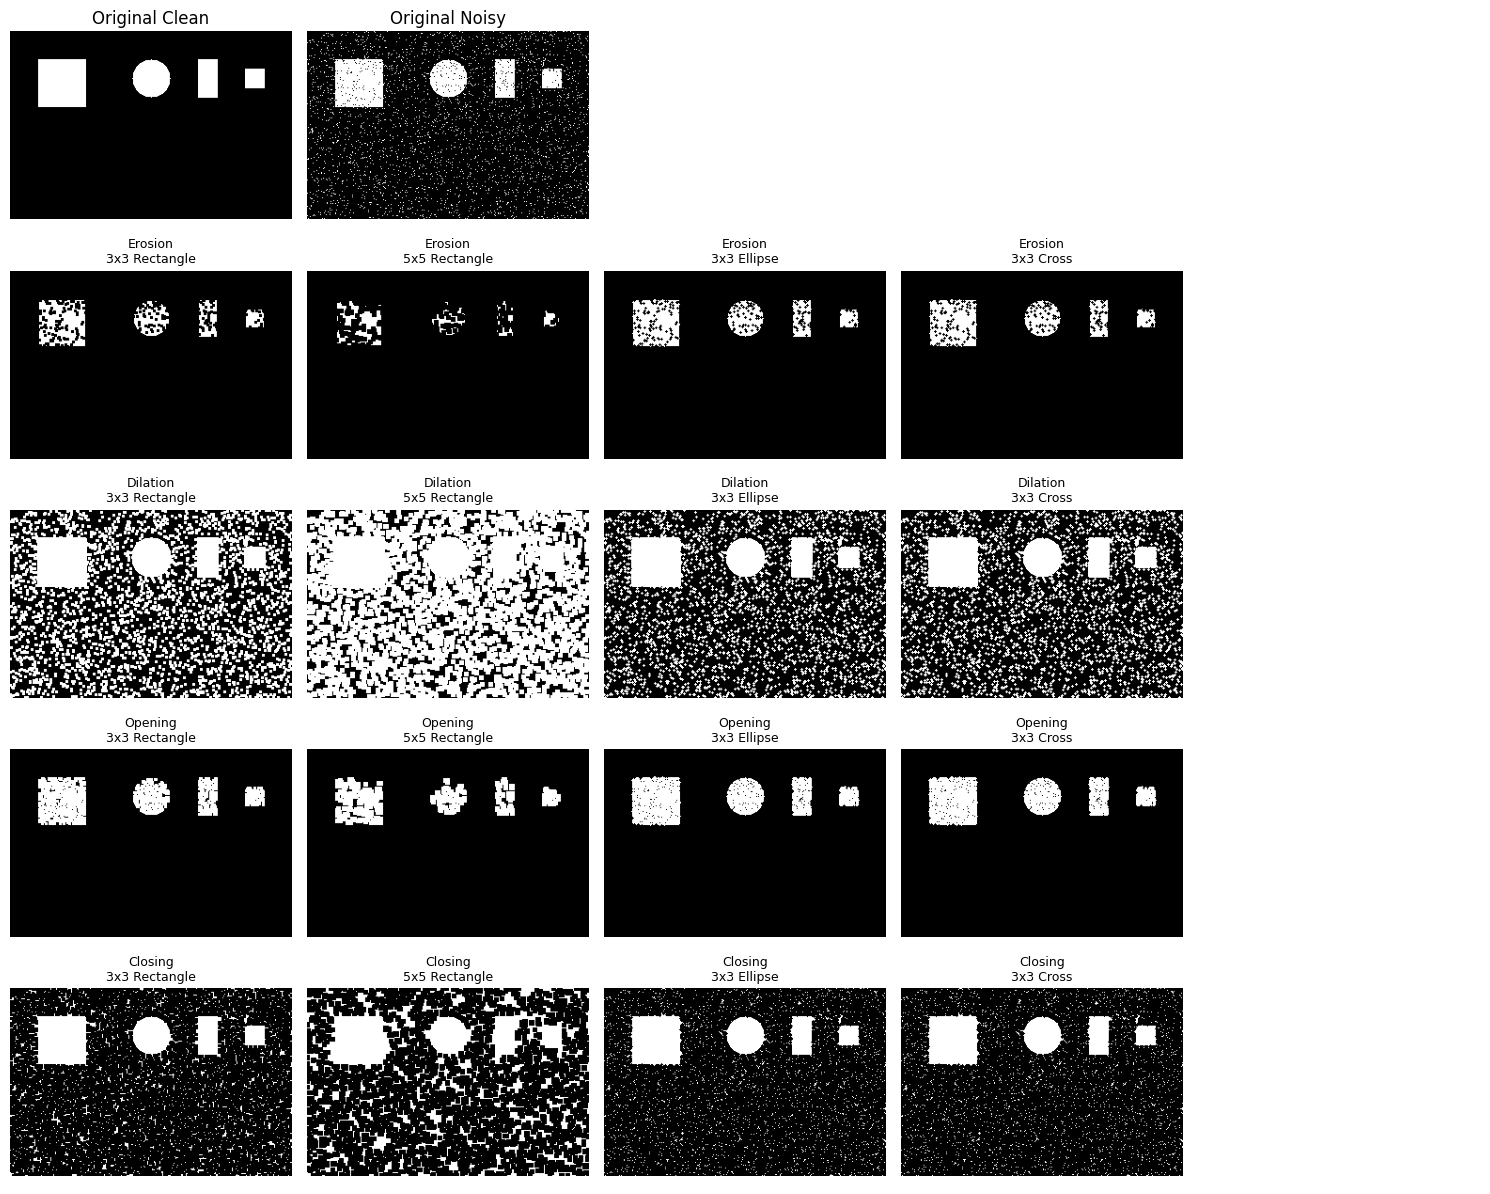

ANALYSIS OF MORPHOLOGICAL OPERATIONS:
1. Erosion:
   - Menghilangkan noise kecil
   - Mengecilkan objek
   - Dapat memisahkan objek yang menyatu

2. Dilation:
   - Mengisi lubang kecil
   - Membesarkan objek
   - Dapat menyambungkan objek terpisah

3. Opening (Erosion lalu Dilation):
   - Menghilangkan noise tanpa mengubah ukuran objek
   - Efektif untuk noise removal

4. Closing (Dilation lalu Erosion):
   - Mengisi lubang tanpa mengubah ukuran objek
   - Efektif untuk hole filling


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def latihan_1():
    # Buat citra biner test pattern
    img = np.zeros((200, 300), dtype=np.uint8)
    
    # Tambahkan berbagai bentuk
    cv2.rectangle(img, (30, 30), (80, 80), 255, -1)      # Square
    cv2.circle(img, (150, 50), 20, 255, -1)              # Circle
    cv2.rectangle(img, (200, 30), (220, 70), 255, -1)    # Vertical line
    cv2.rectangle(img, (250, 40), (270, 60), 255, -1)    # Horizontal line
    
    # Tambahkan noise (salt and pepper)
    noise = np.random.random(img.shape) < 0.05
    img_noisy = img.copy()
    img_noisy[noise] = 255 - img_noisy[noise]
    
    # Define structuring elements
    kernels = {
        '3x3 Rectangle': cv2.getStructuringElement(cv2.MORPH_RECT, (3,3)),
        '5x5 Rectangle': cv2.getStructuringElement(cv2.MORPH_RECT, (5,5)),
        '3x3 Ellipse': cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,3)),
        '3x3 Cross': cv2.getStructuringElement(cv2.MORPH_CROSS, (3,3))
    }
    
    # Ganti grid menjadi 5 baris x 5 kolom (cukup untuk 18 gambar)
    fig, axes = plt.subplots(5, 5, figsize=(15, 12))
    
    # Baris 0: Gambar original (kolom 0 dan 1)
    axes[0,0].imshow(img, cmap='gray')
    axes[0,0].set_title('Original Clean')
    axes[0,0].axis('off')
    
    axes[0,1].imshow(img_noisy, cmap='gray')
    axes[0,1].set_title('Original Noisy')
    axes[0,1].axis('off')
    
    # Matikan sisa kolom di baris 0 (opsional)
    for j in range(2, 5):
        axes[0,j].axis('off')
    
    # Baris 1-4: Operasi morfologi
    operations = ['Erosion', 'Dilation', 'Opening', 'Closing']
    
    for row, op_name in enumerate(operations, start=1):  # row = 1,2,3,4
        for col, (kernel_name, kernel) in enumerate(kernels.items()):
            if op_name == 'Erosion':
                result = cv2.erode(img_noisy, kernel, iterations=1)
            elif op_name == 'Dilation':
                result = cv2.dilate(img_noisy, kernel, iterations=1)
            elif op_name == 'Opening':
                result = cv2.morphologyEx(img_noisy, cv2.MORPH_OPEN, kernel)
            elif op_name == 'Closing':
                result = cv2.morphologyEx(img_noisy, cv2.MORPH_CLOSE, kernel)
            
            axes[row, col].imshow(result, cmap='gray')
            axes[row, col].set_title(f'{op_name}\n{kernel_name}', fontsize=9)
            axes[row, col].axis('off')
        
        # Jika jumlah kernel kurang dari 5, matikan kolom sisa (di sini kernel ada 4, kolom 4 kosong)
        if len(kernels) < 5:
            for col in range(len(kernels), 5):
                axes[row, col].axis('off')
    
    # Matikan seluruh subplot yang tidak terpakai (baris 5 jika ada, tapi grid kita 5 baris sudah penuh)
    # Tidak perlu karena kita pakai semua baris.
    
    plt.tight_layout()
    plt.show()
    
    # Analisis hasil (tetap)
    print("ANALYSIS OF MORPHOLOGICAL OPERATIONS:")
    print("=" * 50)
    print("1. Erosion:")
    print("   - Menghilangkan noise kecil")
    print("   - Mengecilkan objek")
    print("   - Dapat memisahkan objek yang menyatu")
    
    print("\n2. Dilation:")
    print("   - Mengisi lubang kecil")
    print("   - Membesarkan objek")
    print("   - Dapat menyambungkan objek terpisah")
    
    print("\n3. Opening (Erosion lalu Dilation):")
    print("   - Menghilangkan noise tanpa mengubah ukuran objek")
    print("   - Efektif untuk noise removal")
    
    print("\n4. Closing (Dilation lalu Erosion):")
    print("   - Mengisi lubang tanpa mengubah ukuran objek")
    print("   - Efektif untuk hole filling")

# Jalankan latihan 1
latihan_1()